# Install requirements


In [1]:
pip install torch torchvision matplotlib numpy SimpleITK ipywidgets jupyterlab_widgets --extra-index-url https://download.pytorch.org/whl/cu117

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu117
Note: you may need to restart the kernel to use updated packages.


# Imports


In [1]:
import os
import random
import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn as nn
import torchvision.transforms
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm import tqdm
import torchmetrics

# Setup up some config


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

DATASET_PATH = "C:\\bratsdata"
DATASET_PROCESSED_PATH = "C:\\bratsdata_processed"
MODEL_FOLDER_PATH = "./output_models"
CHECKPOINT_PATH = "checkpoint.pt"

INPUT_CHANNELS = 4
OUTPUT_CHANNELS = 4

IMAGE_WIDTH = 64 
IMAGE_HEIGHT = 64 

BATCH_SIZE = 4
LEARNING_RATE = 0.0001  # 0.0001
NUM_EPOCHS = 10

MODEL_PATH = (
    MODEL_FOLDER_PATH + f"/unet_model_{str(datetime.now().day)}-{str(datetime.now().month)}-{str(datetime.now().year)}_B{BATCH_SIZE}_L{LEARNING_RATE}_E{NUM_EPOCHS}_WH{IMAGE_WIDTH}.pt"
)
TEST_VALIDATION_SPLIT = 0.2
SEED = 126728


# Prepare the paths


In [4]:
class Paths:
    def __init__(self, root_path):
        self.root_path = root_path
        self.file_list = os.listdir(root_path)

    def get_file_path_list(self, mri_type="t1"):
        path_list = []
        mask_list = []
        for index in range(len(self.file_list)):
            path_list.append(self.get_file_path(index, mri_type))
            mask_list.append(self.get_file_path(index, mask=True))
        return np.array(path_list), np.array(mask_list)

    def get_file_path_list_multi_channel(self, discard_channels=[]):
        mri_type_list = ["t1", "t1ce", "t2", "flair"]
        path_list = []
        mask_list = []
        for index in range(len(self.file_list)):
            channels = []
            for mri_type in mri_type_list:
                channels.append(self.get_file_path(index, mri_type))
            path_list.append(channels)
            mask_list.append(self.get_file_path(index, mask=True))
        return np.array(path_list), np.array(mask_list)

    def get_file_path(self, index: int, mri_type="t1", mask: bool = False):
        name = (
            self.__get_label_image_name(index)
            if mask
            else self.__get_image_name(index, mri_type)
        )
        return os.path.join(self.root_path, self.file_list[index], name)

    def __get_image_name(self, index: int, mri_type: str):
        return self.file_list[index] + "_" + mri_type + ".nii.gz"

    def __get_label_image_name(self, index: int):
        return self.file_list[index] + "_seg.nii.gz"


# Preprocess Data

1. Shrink image size to 128x64x64
2. Normalize images between 0 and 1
3. Save image and label to file
   1. loaded["img"]
   2. loaded["label"]


In [5]:
def __get_numpy_array(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(path, sitk.sitkInt16))


def __reshape_slices(obj):
    return obj[14:142, ...]


def __resize_image(obj):
    return torchvision.transforms.Resize(size=(IMAGE_WIDTH, IMAGE_HEIGHT))(obj)


def preprocess_image(img):
    processed_image = torch.from_numpy(img).to(torch.float)
    processed_image = torch.nn.functional.normalize(processed_image)
    processed_image = __reshape_slices(processed_image)
    processed_image = __resize_image(processed_image)
    processed_image = processed_image.to(torch.float)
    return processed_image


def preprocess_label(label):
    label[label == 4] = 3
    mask = __reshape_slices(label)
    new_mask = torch.from_numpy(mask)
    new_mask = __resize_image(new_mask)
    new_mask = torch.nn.functional.one_hot(new_mask.long(), num_classes=4)
    new_mask = new_mask.to(torch.float)
    new_mask = new_mask.movedim(-1, 0)
    new_mask = new_mask.to(torch.long)
    return new_mask


save_path = "C:\\bratsdata_processed"
if not os.path.exists(save_path):
    os.mkdir(save_path)

image_paths, label_paths = Paths(DATASET_PATH).get_file_path_list_multi_channel()
for imgs_path, label_path in zip(image_paths, label_paths):
    x = []
    for single_img_path in imgs_path:
        img = preprocess_image(__get_numpy_array(single_img_path))
        x.append(img)
    x = np.stack(x)
    y = preprocess_label(__get_numpy_array(label_path))
    # Splits the label path into string wihtout extension and what kind of image
    # Before: C:\\bratsdata\\BraTS2021_000000\\BraTS2021_00000_seg.nii.gz
    # AfteR:  C:\\bratsdata\\BraTS2021_000000\\BraTS2021_00000
    path = save_path + "\\" + label_path.split("\\")[2]
    np.savez_compressed(path, img=x, label=y)


# Load data to verify

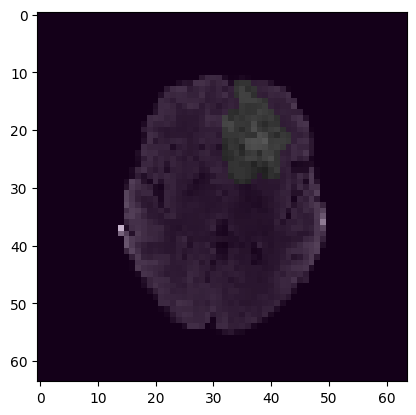

In [5]:
processed_file_paths = os.listdir(DATASET_PROCESSED_PATH)
loaded = np.load(DATASET_PROCESSED_PATH+ "\\" + processed_file_paths[0])
img = loaded["img"]
label = loaded["label"]
label = label.astype(float)
label[label == 0] = np.nan
plt.imshow(img[3][59], cmap="gray")
plt.imshow(label[0][59], alpha=0.3, cmap="viridis")


# Setup the Dataset

torch.Size([4, 128, 64, 64]) torch.Size([4, 128, 64, 64])


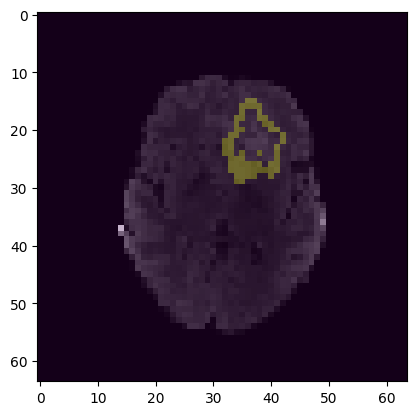

In [3]:
class BratsDataset(Dataset):
    def __init__(self, paths, transforms=None):
        super().__init__()
        self.paths = paths
        self.transforms = transforms

    def __getitem__(self, index):
        loaded = np.load(self.paths[index])
        img, label = torch.from_numpy(loaded["img"]), torch.from_numpy(loaded["label"])
        if self.transforms != None:
            # Apply transforms also on label because label is an image mask
            both = torch.cat((img.unsqueeze(0), label.unsqueeze(0)), 0)
            both_transformed = self.transforms(both)
            img, label = both_transformed[0], both_transformed[1]
        return img, label

    def __len__(self):
        return len(self.paths)


file_paths = [
    DATASET_PROCESSED_PATH + "\\" + single_path
    for single_path in os.listdir(DATASET_PROCESSED_PATH)
]
transformations = transforms.Compose(
    [
        #transforms.RandomRotation(90),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
    ]
)
dataset = BratsDataset(file_paths, transformations)
img, label = next(iter(dataset))
print(img.shape, label.shape)
plt.imshow(img[3][59], cmap="gray")
plt.imshow(label[3][59], alpha=0.3, cmap="viridis")


# Setup the model

In [4]:
class InConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(InConv, self).__init__()
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        x = self.conv(x)
        return x


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Down, self).__init__()
        self.mpconv = nn.Sequential(nn.MaxPool3d(2, 2), DoubleConv(in_ch, out_ch))

    def forward(self, x):
        x = self.mpconv(x)
        return x


class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(OutConv, self).__init__()
        self.conv = nn.Conv3d(in_ch, out_ch, 1)

    def forward(self, x):
        x = self.conv(x)
        return x


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.conv(x)
        return x


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super(Up, self).__init__()
        self.up = nn.ConvTranspose3d(in_ch, in_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        x = self.conv(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, features=[16, 32, 64, 96]):
        super(UNet, self).__init__()
        # features = [32, 64, 128, 256]
        # features = [64, 128, 256, 512]
        features[:] = [x // 2 for x in features]

        self.inc = InConv(in_channels, features[0])
        self.down1 = Down(features[0], features[1])
        self.down2 = Down(features[1], features[2])
        self.down3 = Down(features[2], features[3])
        self.down4 = Down(features[3], features[3])

        self.up1 = Up(features[3], features[3], features[2])
        self.up2 = Up(features[2], features[2], features[1])
        self.up3 = Up(features[1], features[1], features[0])
        self.up4 = Up(features[0], features[0], features[0])
        self.outc = OutConv(features[0], out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        x = self.outc(x)
        return x


# Setup everything for training the model

In [8]:
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):

        # comment out if your model contains a sigmoid or equivalent activation layer
        inputs = nn.functional.sigmoid(inputs)

        # flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2.0 * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)

        return 1 - dice

In [9]:
file_paths = [
    DATASET_PROCESSED_PATH + "\\" + single_path
    for single_path in os.listdir(DATASET_PROCESSED_PATH)
]

transformations = nn.Sequential(
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    # transforms.RandomRotation(90),
)

dataset = BratsDataset(file_paths, transformations)

train_dataset, test_dataset = random_split(
    dataset, [0.8, 0.2], torch.Generator().manual_seed(42)
)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    pin_memory=PIN_MEMORY,
    # num_workers=os.cpu_count(),
)
test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    pin_memory=PIN_MEMORY,
    # num_workers=os.cpu_count(),
)

model = UNet(
    in_channels=INPUT_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    features=[8, 16, 32, 64],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# criterion = nn.CrossEntropyLoss()
criterion = DiceLoss()


# Train

In [10]:
print(f"[INFO] Start training network...")
model = UNet(
    in_channels=INPUT_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    features=[8, 16, 32, 64],
).to(DEVICE)
start_time = time.time()
model.train()
acc = torchmetrics.JaccardIndex(
    task="multiclass",
    num_classes=4,
).to(DEVICE)
for epoch in range(NUM_EPOCHS):
    running_loss = 0.0
    for inputs, labels in tqdm(
        train_loader, unit="batches", desc=f"[Epoch {epoch+1}|Train]"
    ):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(inputs)
        loss = criterion(outputs, labels.float())
       
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        acc.update(outputs.softmax(dim=1), labels.argmax(dim=1).long())
        running_loss += loss.item()

    print(
        f"[Epoch {epoch + 1}|Train] Loss: {running_loss / len(train_loader):.4f}, Acc: {acc.compute():.2f}"
    )

    model.eval()
    val_loss = 0.0
    val_acc = torchmetrics.JaccardIndex(
        task="multiclass",
        num_classes=4,
    ).to(DEVICE)
    with torch.no_grad():
        for inputs, labels in test_loader:
            # Move the inputs and labels to the specified device
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels.float())
            val_loss += loss.item()
            val_acc.update(outputs.softmax(dim=1), labels.argmax(dim=1).long())
    print(
        f"[Epoch {epoch + 1}|Val] Loss: {val_loss / len(test_loader):.4f} | Val Acc: {val_acc.compute():.2f} "
    )

torch.save(model.state_dict(), MODEL_PATH)


[INFO] Start training network...


[Epoch 1|Train]:   0%|          | 0/251 [00:00<?, ?batches/s]d:\Programmierung\Studium\T3000\python_brats\.venv\lib\site-packages\torch\nn\functional.py:1967: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")
[Epoch 1|Train]: 100%|██████████| 251/251 [01:39<00:00,  2.51batches/s]


[Epoch 1|Train] Loss: 0.6428, Acc: 0.02
[Epoch 1|Val] Loss: 0.6427 | Val Acc: 0.02 


[Epoch 2|Train]: 100%|██████████| 251/251 [01:32<00:00,  2.70batches/s]


[Epoch 2|Train] Loss: 0.6427, Acc: 0.02
[Epoch 2|Val] Loss: 0.6427 | Val Acc: 0.02 


[Epoch 3|Train]:  50%|████▉     | 125/251 [00:46<00:47,  2.68batches/s]


KeyboardInterrupt: 

IoU: tensor([0.2488, 0.2464, 0.2492, 0.2488], device='cuda:0')
tensor(0) tensor([0])
torch.Size([4, 128, 64, 64])


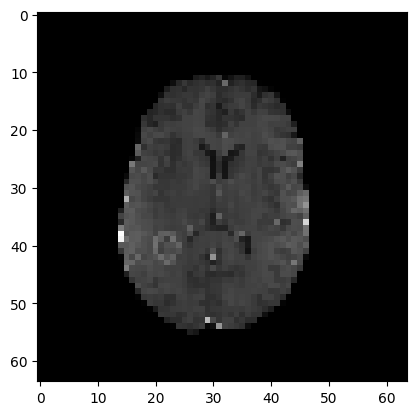

In [40]:
model = UNet(
    in_channels=INPUT_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    features=[8, 16, 32, 64],
).to(DEVICE)
model.load_state_dict(
   torch.load("output_models/unet_model_5-2-2023_B2_L0.0001_E5_WH64.pt")
)
model.eval()
def mean_iou(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred.argmax(dim=1) == cls).float()
        target_cls = (target.argmax(dim=1) == cls).float()
        intersection = (pred_cls * target_cls).sum(dim=(1, 2, 3))
        union = (
            pred_cls.sum(dim=(1, 2, 3)) + target_cls.sum(dim=(1, 2, 3)) - intersection
        )
        iou = intersection / union
        ious.append(iou)
    return torch.mean(torch.stack(ious, dim=0), dim=0)




def iou(pred, target, num_classes):
    ious = []
    for class_idx in range(num_classes):
        class_pred = (torch.sigmoid(pred[:, class_idx, :, :, :]) > 0.5).float()
        class_target = (target[:, class_idx, :, :, :] > 0.5).float()
        inter = torch.sum(torch.mul(class_pred, class_target), dim=(1, 2, 3))
        union = torch.sum(class_pred, dim=(1, 2, 3)) + torch.sum(class_target, dim=(1, 2, 3)) - inter
        iou = torch.div(inter, union)
        ious.append(iou)
    return torch.stack(ious).mean()

for input, label in test_loader:
    inputs = input.to(DEVICE)
    labels = label.to(DEVICE)
    # Forward pass
    outputs = model(inputs)
    # acc.update(outputs, labels)
    print("IoU:",mean_iou(outputs,labels,4))
    softmax = torch.softmax(outputs, dim=1)
    argmaxed = torch.argmax(softmax, 1)
    outputs = argmaxed.cpu()  # outputs = torch.softmax(outputs.detach(), dim=1)
    print(torch.max(outputs), torch.unique(outputs))
    plt.imshow(inputs.cpu()[0][1][59], cmap="gray")
    outputs = outputs.float()
    outputs[outputs == 0] = torch.nan
    # plt.imshow(labels.cpu()[0][1][59], alpha=0.3, cmap="gray")
    plt.imshow(outputs[0][59], alpha=0.3, cmap="viridis")
    print(outputs.shape)
    # plt.imshow(outputs[1][59], alpha=0.3, cmap="viridis")
    break


In [64]:
def mean_iou(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred.argmax(dim=1) == cls).float()
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum(dim=(1, 2, 3))
        union = (
            pred_cls.sum(dim=(1, 2, 3)) + target_cls.sum(dim=(1, 2, 3)) - intersection
        )
        iou = intersection / union
        ious.append(iou)
    return torch.mean(torch.stack(ious, dim=0), dim=0)


a = torch.tensor([[[[[0, 1], [1, 1,]], [[0, 0], [1, 0, ]]]]])
b = torch.tensor([[[[[1, 1], [1, 1,]], [[0, 0], [1, 0, ]]]]])
print(a.shape)

mean_iou(a,b,3)


torch.Size([1, 1, 2, 2, 2])


tensor([[nan, nan]])